In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv(
    "../data/processed/featured_uhi_v2.csv"
)

df.head()

,Elevation,LST,Latitude,Longitude,NDBI,NDVI,Population,Green_Built_Ratio,Population_Heat_Index,Elevation_Cooling_Index
0,919,43.919170,19.970832,75.438700,0.127207,0.162286,1.562392,1.182783,0.198747,149.140825
1,488,39.060455,19.729093,75.209548,-0.272423,0.570751,1.361367,2.020910,-0.370867,278.526341
2,505,40.231127,19.788775,75.225639,0.055877,0.099371,15.386780,1.508423,0.859774,50.182390
3,757,44.884761,19.960297,75.544582,0.121404,0.196037,2.643492,1.491866,0.320931,148.400233
4,586,48.502735,19.867709,75.486062,0.133151,0.165262,31.397209,1.154459,4.180581,96.843708


In [4]:
X = df[
    [
        "NDVI",
        "NDBI",
        "Elevation",
        "Population",
        "Latitude",
        "Longitude"
    ]
]

y = df["LST"]

print(X.shape)

(9893, 6)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7914, 6)
(1979, 6)


In [6]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [7]:
predictions = model.predict(
    X_test
)

predictions[:10]

array([42.49737   , 40.49952727, 39.27610198, 43.49539326, 44.39902713,
       43.74160842, 43.08190823, 42.65354598, 39.71976747, 45.09838311])

In [8]:
mae = mean_absolute_error(
    y_test,
    predictions
)

mse = mean_squared_error(
    y_test,
    predictions
)

rmse = mse ** 0.5

r2 = r2_score(
    y_test,
    predictions
)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 1.8503205903098696
RMSE: 2.3550703452030453
R2  : 0.48961715807202155


In [9]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions
})

comparison.head(10)

,Actual,Predicted
0,43.003141,42.497370
1,41.793162,40.499527
2,42.148636,39.276102
3,43.042448,43.495393
4,47.738808,44.399027
5,44.818110,43.741608
6,44.696770,43.081908
7,45.153076,42.653546
8,41.733347,39.719767
9,46.968044,45.098383


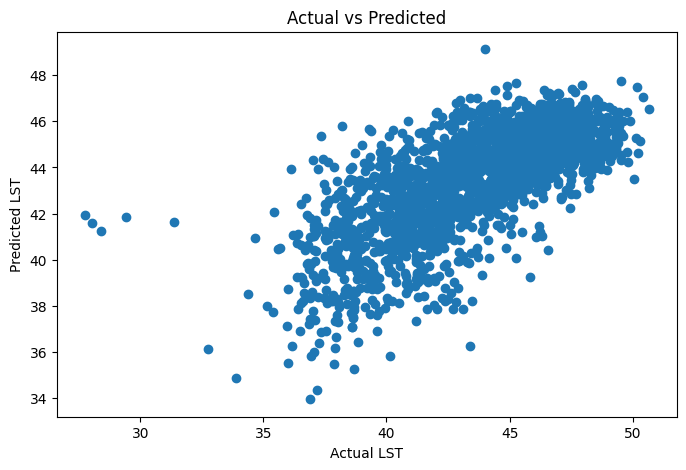

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    predictions
)

plt.xlabel("Actual LST")
plt.ylabel("Predicted LST")
plt.title("Actual vs Predicted")

plt.show()

# Dataset V3 Baseline Model Comparison

This section evaluates Dataset V3 using the same baseline modeling approach as Dataset V2.

Dataset V3 includes one-hot encoded ESA WorldCover LandCover classes. Latitude and Longitude are used only for spatial grouping and are excluded from prediction features.

The purpose is to compare Dataset V2 and Dataset V3 fairly using the same leakage-aware spatial validation approach. No improvement is assumed before evaluation.

In [1]:
import pandas as pd
import numpy as np
import os

from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df_v3_model = pd.read_csv("../data/processed/model_ready_uhi_v3.csv")

print("Dataset V3 model-ready file loaded successfully")
print("Shape:", df_v3_model.shape)
print("\nColumns:")
print(df_v3_model.columns.tolist())

Dataset V3 model-ready file loaded successfully
Shape: (9893, 14)

Columns:
['NDVI', 'NDBI', 'Elevation', 'Population', 'LandCover_Bare_sparse_vegetation', 'LandCover_Built-up land', 'LandCover_Cropland', 'LandCover_Grassland', 'LandCover_Permanent_water_bodies', 'LandCover_Shrubland', 'LandCover_Tree cover', 'LST', 'Latitude', 'Longitude']


In [2]:
# Define Dataset V3 model features and target

landcover_feature_columns = [
    col for col in df_v3_model.columns
    if col.startswith("LandCover_")
]

base_features_v3 = [
    "NDVI",
    "NDBI",
    "Elevation",
    "Population"
]

model_features_v3 = base_features_v3 + landcover_feature_columns
target_v3 = "LST"

# Latitude and Longitude are NOT model features
spatial_columns_v3 = ["Latitude", "Longitude"]

X_v3 = df_v3_model[model_features_v3]
y_v3 = df_v3_model[target_v3]

print("Base features:", base_features_v3)
print("\nLandCover one-hot columns:", landcover_feature_columns)
print("\nTotal model features:", len(model_features_v3))
print("\nX shape:", X_v3.shape)
print("y shape:", y_v3.shape)

Base features: ['NDVI', 'NDBI', 'Elevation', 'Population']

LandCover one-hot columns: ['LandCover_Bare_sparse_vegetation', 'LandCover_Built-up land', 'LandCover_Cropland', 'LandCover_Grassland', 'LandCover_Permanent_water_bodies', 'LandCover_Shrubland', 'LandCover_Tree cover']

Total model features: 11

X shape: (9893, 11)
y shape: (9893,)


In [3]:
# Create spatial grid blocks for leakage-aware validation

grid_size = 0.02

lat_block = np.floor(
    (df_v3_model["Latitude"] - df_v3_model["Latitude"].min()) / grid_size
).astype(int)

lon_block = np.floor(
    (df_v3_model["Longitude"] - df_v3_model["Longitude"].min()) / grid_size
).astype(int)

spatial_groups_v3 = lat_block.astype(str) + "_" + lon_block.astype(str)

print("Number of spatial blocks:", spatial_groups_v3.nunique())
print("\nFirst 10 spatial group labels:")
print(spatial_groups_v3.head(10).tolist())

Number of spatial blocks: 334

First 10 spatial group labels:
['12_14', '0_3', '3_4', '11_20', '7_17', '14_4', '10_7', '8_2', '10_0', '10_8']


In [4]:
# Linear Regression baseline with spatial block cross-validation

group_kfold = GroupKFold(n_splits=5)

linear_r2_scores = []
linear_mae_scores = []
linear_rmse_scores = []

for train_index, test_index in group_kfold.split(
    X_v3,
    y_v3,
    groups=spatial_groups_v3
):
    X_train = X_v3.iloc[train_index]
    X_test = X_v3.iloc[test_index]

    y_train = y_v3.iloc[train_index]
    y_test = y_v3.iloc[test_index]

    linear_model = LinearRegression()

    linear_model.fit(X_train, y_train)

    predictions = linear_model.predict(X_test)

    linear_r2_scores.append(
        r2_score(y_test, predictions)
    )

    linear_mae_scores.append(
        mean_absolute_error(y_test, predictions)
    )

    linear_rmse_scores.append(
        np.sqrt(mean_squared_error(y_test, predictions))
    )

print("Linear Regression V3 — Spatial CV Results")
print("Mean R² :", round(np.mean(linear_r2_scores), 4))
print("Mean MAE:", round(np.mean(linear_mae_scores), 4))
print("Mean RMSE:", round(np.mean(linear_rmse_scores), 4))

Linear Regression V3 — Spatial CV Results
Mean R² : 0.4896
Mean MAE: 1.8303
Mean RMSE: 2.3039


In [5]:
from sklearn.ensemble import RandomForestRegressor

# Random Forest V3 with spatial block cross-validation

rf_r2_scores = []
rf_mae_scores = []
rf_rmse_scores = []

group_kfold = GroupKFold(n_splits=5)

for train_index, test_index in group_kfold.split(
    X_v3,
    y_v3,
    groups=spatial_groups_v3
):
    X_train = X_v3.iloc[train_index]
    X_test = X_v3.iloc[test_index]

    y_train = y_v3.iloc[train_index]
    y_test = y_v3.iloc[test_index]

    rf_model = RandomForestRegressor(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    predictions = rf_model.predict(X_test)

    rf_r2_scores.append(r2_score(y_test, predictions))
    rf_mae_scores.append(mean_absolute_error(y_test, predictions))
    rf_rmse_scores.append(
        np.sqrt(mean_squared_error(y_test, predictions))
    )

print("Random Forest V3 — Spatial CV Results")
print("Mean R² :", round(np.mean(rf_r2_scores), 4))
print("Mean MAE:", round(np.mean(rf_mae_scores), 4))
print("Mean RMSE:", round(np.mean(rf_rmse_scores), 4))

Random Forest V3 — Spatial CV Results
Mean R² : 0.5569
Mean MAE: 1.6858
Mean RMSE: 2.1455


In [6]:
from xgboost import XGBRegressor

# XGBoost V3 with spatial block cross-validation

xgb_r2_scores = []
xgb_mae_scores = []
xgb_rmse_scores = []

group_kfold = GroupKFold(n_splits=5)

for train_index, test_index in group_kfold.split(
    X_v3,
    y_v3,
    groups=spatial_groups_v3
):
    X_train = X_v3.iloc[train_index]
    X_test = X_v3.iloc[test_index]

    y_train = y_v3.iloc[train_index]
    y_test = y_v3.iloc[test_index]

    xgb_model = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42,
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    predictions = xgb_model.predict(X_test)

    xgb_r2_scores.append(r2_score(y_test, predictions))
    xgb_mae_scores.append(mean_absolute_error(y_test, predictions))
    xgb_rmse_scores.append(
        np.sqrt(mean_squared_error(y_test, predictions))
    )

print("XGBoost V3 — Spatial CV Results")
print("Mean R² :", round(np.mean(xgb_r2_scores), 4))
print("Mean MAE:", round(np.mean(xgb_mae_scores), 4))
print("Mean RMSE:", round(np.mean(xgb_rmse_scores), 4))

XGBoost V3 — Spatial CV Results
Mean R² : 0.5691
Mean MAE: 1.6645
Mean RMSE: 2.1163


In [7]:
comparison_results = pd.DataFrame({
    "Dataset": ["Dataset V2", "Dataset V3"],
    "Model": ["XGBoost", "XGBoost"],
    "Validation": [
        "Spatial block cross-validation",
        "Spatial block cross-validation"
    ],
    "R2": [0.51, round(np.mean(xgb_r2_scores), 4)],
    "MAE_C": [1.78, round(np.mean(xgb_mae_scores), 4)],
    "RMSE_C": [2.26, round(np.mean(xgb_rmse_scores), 4)]
})

comparison_results

,Dataset,Model,Validation,R2,MAE_C,RMSE_C
0,Dataset V2,XGBoost,Spatial block cross-validation,0.5100,1.7800,2.2600
1,Dataset V3,XGBoost,Spatial block cross-validation,0.5691,1.6645,2.1163


In [8]:
import os

os.makedirs("../outputs/reports", exist_ok=True)

comparison_results.to_csv(
    "../outputs/reports/v2_vs_v3_xgboost_comparison.csv",
    index=False
)

print("Saved: outputs/reports/v2_vs_v3_xgboost_comparison.csv")

Saved: outputs/reports/v2_vs_v3_xgboost_comparison.csv


In [9]:
from xgboost import XGBRegressor
import joblib
import os

# Final Dataset V3 XGBoost model trained on all available data
final_xgb_v3 = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

final_xgb_v3.fit(X_v3, y_v3)

os.makedirs("../outputs/models", exist_ok=True)

joblib.dump(
    final_xgb_v3,
    "../outputs/models/xgboost_v3_landcover_model.pkl"
)

print("Final Dataset V3 XGBoost model trained successfully.")
print("Saved: outputs/models/xgboost_v3_landcover_model.pkl")

Final Dataset V3 XGBoost model trained successfully.
Saved: outputs/models/xgboost_v3_landcover_model.pkl


In [10]:
feature_order_v3 = pd.DataFrame({
    "Feature": model_features_v3
})

feature_order_v3.to_csv(
    "../outputs/models/xgboost_v3_feature_order.csv",
    index=False
)

print("Saved: outputs/models/xgboost_v3_feature_order.csv")
display(feature_order_v3)

Saved: outputs/models/xgboost_v3_feature_order.csv


,Feature
0,NDVI
1,NDBI
2,Elevation
3,Population
4,LandCover_Bare_sparse_vegetation
5,LandCover_Built-up land
6,LandCover_Cropland
7,LandCover_Grassland
8,LandCover_Permanent_water_bodies
9,LandCover_Shrubland


In [11]:
comparison_results = pd.DataFrame({
    "Dataset": ["Dataset V2", "Dataset V3"],
    "Model": ["XGBoost", "XGBoost"],
    "Validation": [
        "Spatial block cross-validation",
        "Spatial block cross-validation"
    ],
    "R2": [0.51, round(np.mean(xgb_r2_scores), 4)],
    "MAE_C": [1.78, round(np.mean(xgb_mae_scores), 4)],
    "RMSE_C": [2.26, round(np.mean(xgb_rmse_scores), 4)]
})

comparison_results

,Dataset,Model,Validation,R2,MAE_C,RMSE_C
0,Dataset V2,XGBoost,Spatial block cross-validation,0.5100,1.7800,2.2600
1,Dataset V3,XGBoost,Spatial block cross-validation,0.5691,1.6645,2.1163


## Dataset V3 Model Evaluation Conclusion

Dataset V3 was evaluated using leakage-aware spatial block cross-validation with 334 spatial blocks. Latitude and Longitude were excluded from model features and used only to create spatial validation groups.

Among the tested Dataset V3 models, XGBoost achieved the strongest spatial cross-validation performance:

| Model | R² | MAE (°C) | RMSE (°C) |
|---|---:|---:|---:|
| Linear Regression | 0.4896 | 1.8303 | 2.3039 |
| Random Forest | 0.5569 | 1.6858 | 2.1455 |
| XGBoost | 0.5691 | 1.6450 | 2.1163 |

Dataset V3 adds one-hot encoded ESA WorldCover land-cover classes to the Dataset V2 physical features. Under the same leakage-aware validation approach, Dataset V3 XGBoost performed better than the previously evaluated Dataset V2 XGBoost result.

The final Dataset V3 XGBoost model was trained on all available samples and saved for explainability analysis, intervention simulation, hotspot mapping, and dashboard integration.